In [ ]:
!pip install yfinance pandas numpy -q

In [ ]:
import os
import numpy as np
import pandas as pd
import yfinance as yf

# === Config ===
RAW_DATA_DIR = "data/raw"
PROCESSED_DATA_DIR = "data/processed"
SPX_YF_TICKER = "^GSPC"
START_DATE = "2005-01-01"
END_DATE = "2025-12-31"
WINDOW = 60  # Transformer rolling window (each day = one token)

os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# VIX tickers
VIX_YF_MAP = {
    "VIX":   "^VIX",
    "VIX3M": "^VIX3M",
    "VIX6M": "^VIX6M",
    "VIX1Y": "^VIX1Y",
}


In [ ]:
def fetch_spx_daily() -> pd.DataFrame:
    """Download SPX daily OHLCV from Yahoo Finance."""
    path = os.path.join(RAW_DATA_DIR, "spx_daily.csv")
    if os.path.exists(path):
        print(f"  [cache] Loading {path}")
        return pd.read_csv(path, index_col="Date", parse_dates=True)

    print("  Downloading SPX daily from Yahoo Finance...")
    df = yf.download(SPX_YF_TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
    df.to_csv(path)
    print(f"  Saved -> {path}  ({len(df)} rows)")
    return df


def build_spx_features(spx: pd.DataFrame) -> pd.DataFrame:
    """
    Build daily features from SPX OHLCV:
      - log_return:     ln(close_t / close_{t-1})
      - abs_return:     magnitude of daily move
      - return_5d:      5-day cumulative return
      - return_22d:     22-day cumulative return
      - vol_5d:         5-day rolling volatility (annualized)
      - vol_22d:        22-day rolling volatility (annualized)
      - volume_zscore:  how unusual today's volume is vs last 22 days
      - parkinson_vol:  range-based intraday vol estimate (annualized)
      - rsi_14:         14-day relative strength index
    """
    close = spx["Close"].squeeze()
    volume = spx["Volume"].squeeze()
    high = spx["High"].squeeze()
    low = spx["Low"].squeeze()

    feat = pd.DataFrame(index=close.index)

    # --- Return features ---
    feat["log_return"] = np.log(close / close.shift(1))
    feat["abs_return"] = feat["log_return"].abs()
    feat["return_5d"] = close.pct_change(5)
    feat["return_22d"] = close.pct_change(22)

    # --- Volatility features ---
    feat["vol_5d"] = feat["log_return"].rolling(5).std() * np.sqrt(252)
    feat["vol_22d"] = feat["log_return"].rolling(22).std() * np.sqrt(252)

    # Parkinson (1980) range-based estimator:
    # Uses high-low range, captures intraday movement that close-to-close misses.
    # A day that drops 3% and recovers looks calm to close-to-close but wild to Parkinson.
    feat["parkinson_vol"] = np.sqrt(
        (1 / (4 * np.log(2))) * (np.log(high / low) ** 2)
    ) * np.sqrt(252)

    # --- Volume features ---
    # Z-score: how many stdev today's volume is from its 22-day rolling mean.
    # High volume confirms moves; low volume on a selloff suggests less conviction.
    feat["volume_zscore"] = (
        (volume - volume.rolling(22).mean()) / volume.rolling(22).std()
    )

    # --- Momentum features ---
    # RSI: 14-day relative strength index.
    # Above 70 = overbought, below 30 = oversold.
    # Extreme readings often precede reversals, which affect vol.
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss
    feat["rsi_14"] = 100 - (100 / (1 + rs))

    return feat


In [ ]:
def fetch_vix_term_structure() -> pd.DataFrame:
    """Download VIX term structure from Yahoo Finance."""
    path = os.path.join(RAW_DATA_DIR, "vix_term_structure.csv")
    if os.path.exists(path):
        print(f"  [cache] Loading {path}")
        return pd.read_csv(path, index_col="Date", parse_dates=True)

    frames = {}
    for label, ticker in VIX_YF_MAP.items():
        print(f"  Downloading {label} ({ticker})...")
        try:
            df = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=True)
            if len(df) > 0:
                frames[label] = df["Close"].squeeze()
                print(f"    -> {len(df)} rows")
            else:
                print(f"    -> empty, skipping")
        except Exception as e:
            print(f"    -> failed ({e}), skipping")

    vix = pd.DataFrame(frames)
    vix.index.name = "Date"
    vix.to_csv(path)
    print(f"  Saved -> {path}  ({len(vix)} rows)")
    return vix


def build_vix_features(vix: pd.DataFrame) -> pd.DataFrame:
    """
    Derive term structure + momentum features from raw VIX levels:
      - slope_3m_spot:    VIX3M - VIX (positive = contango = normal)
      - slope_6m_3m:      VIX6M - VIX3M (far-end of the curve)
      - curvature:        VIX - 2*VIX3M + VIX6M (second derivative)
      - contango_flag:    1 if contango, 0 if backwardated
      - vix_1d_change:    daily pct change in VIX
      - vix_5d_change:    5-day pct change in VIX
      - vix_zscore_20d:   VIX z-score relative to 20-day window
      - vix_ma_ratio:     VIX / 60-day MA (mean reversion signal)
    """
    feat = pd.DataFrame(index=vix.index)

    # Keep raw VIX level (the Transformer can learn level-dependent patterns)
    feat["vix_level"] = vix.get("VIX")

    # Term structure shape
    if "VIX" in vix.columns and "VIX3M" in vix.columns:
        feat["slope_3m_spot"] = vix["VIX3M"] - vix["VIX"]
    if "VIX3M" in vix.columns and "VIX6M" in vix.columns:
        feat["slope_6m_3m"] = vix["VIX6M"] - vix["VIX3M"]
    if all(c in vix.columns for c in ["VIX", "VIX3M", "VIX6M"]):
        feat["curvature"] = vix["VIX"] - 2 * vix["VIX3M"] + vix["VIX6M"]

    # Regime flag
    if "VIX" in vix.columns and "VIX3M" in vix.columns:
        feat["contango_flag"] = (vix["VIX3M"] > vix["VIX"]).astype(int)

    # VIX momentum and mean-reversion
    if "VIX" in vix.columns:
        feat["vix_1d_change"] = vix["VIX"].pct_change()
        feat["vix_5d_change"] = vix["VIX"].pct_change(5)
        feat["vix_zscore_20d"] = (
            (vix["VIX"] - vix["VIX"].rolling(20).mean())
            / vix["VIX"].rolling(20).std()
        )
        feat["vix_ma_ratio"] = vix["VIX"] / vix["VIX"].rolling(60).mean()

    return feat


In [ ]:
def build_synthetic_options_flow(vix_feat: pd.DataFrame) -> pd.DataFrame:
    """
    Without IBKR, derive proxy options flow signals from VIX dynamics.
    The real IBKR data would give us put-call ratio, open interest,
    and volume-weighted IV — these proxies capture directionally
    similar information from freely available data.

      - vix_momentum_5d:     5-day VIX return (proxy for options demand shift)
      - vix_momentum_22d:    22-day VIX return (sustained fear buildup)
      - vix_acceleration:    change in 5d momentum (is fear accelerating?)
      - term_slope_change_5d: is the term structure flattening or steepening?
    """
    flow = pd.DataFrame(index=vix_feat.index)

    if "vix_level" in vix_feat.columns:
        v = vix_feat["vix_level"]
        flow["vix_momentum_5d"] = v.pct_change(5)
        flow["vix_momentum_22d"] = v.pct_change(22)
        # Acceleration: change in momentum (second derivative of VIX)
        flow["vix_acceleration"] = flow["vix_momentum_5d"].diff(5)

    if "slope_3m_spot" in vix_feat.columns:
        flow["term_slope_change_5d"] = vix_feat["slope_3m_spot"].diff(5)

    return flow


In [ ]:
print("=" * 60)
print("P2 — Transformer (Time-Series Attention) Data Pipeline")
print("=" * 60)

# --- SPX features ---
print("\n[1/3] SPX daily features...")
spx = fetch_spx_daily()
spx_feat = build_spx_features(spx)
print(f"  {len(spx_feat)} rows, {spx_feat.shape[1]} features")
print(f"  Features: {list(spx_feat.columns)}")

# --- VIX features ---
print("\n[2/3] VIX term structure features...")
vix_raw = fetch_vix_term_structure()
vix_feat = build_vix_features(vix_raw)
print(f"  {len(vix_feat)} rows, {vix_feat.shape[1]} features")
print(f"  Features: {list(vix_feat.columns)}")

# --- Options flow proxies ---
print("\n[3/3] Synthetic options flow signals (IBKR not available in Colab)...")
flow = build_synthetic_options_flow(vix_feat)
print(f"  {len(flow)} rows, {flow.shape[1]} features")
print(f"  Features: {list(flow.columns)}")

# --- Merge ---
print("\nMerging all features on date index...")
combined = spx_feat.join(vix_feat, how="left").join(flow, how="left")
combined = combined.ffill().dropna()

print(f"\nFinal dataset: {combined.shape[0]} rows x {combined.shape[1]} features")
print(f"Date range: {combined.index.min().date()} to {combined.index.max().date()}")
print(f"60-day windows available: {len(combined) - WINDOW + 1}")
print(f"\nAll features ({combined.shape[1]}):")
for i, col in enumerate(combined.columns):
    print(f"  {i+1:2d}. {col}")

# Save
out_path = os.path.join(PROCESSED_DATA_DIR, "p2_daily_features.csv")
combined.to_csv(out_path)
print(f"\nSaved -> {out_path}")
print("\nDone!")


P2 — Transformer (Time-Series Attention) Data Pipeline

[1/3] SPX daily features...


[*********************100%***********************]  1 of 1 completed


  Saved -> data/raw/spx_daily.csv  (5282 rows)
  5282 rows, 9 features
  Features: ['log_return', 'abs_return', 'return_5d', 'return_22d', 'vol_5d', 'vol_22d', 'parkinson_vol', 'volume_zscore', 'rsi_14']

[2/3] VIX term structure features...


[*********************100%***********************]  1 of 1 completed


    -> 5282 rows


...

    -> 4896 rows


[*********************100%***********************]  1 of 1 completed


    -> 4528 rows


[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^VIX1Y']: YFPricesMissingError('possibly delisted; no price data found  (1d 2005-01-01 -> 2025-12-31)')


    -> empty, skipping
  Saved -> data/raw/vix_term_structure.csv  (5282 rows)
  5282 rows, 9 features
  Features: ['vix_level', 'slope_3m_spot', 'slope_6m_3m', 'curvature', 'contango_flag', 'vix_1d_change', 'vix_5d_change', 'vix_zscore_20d', 'vix_ma_ratio']

[3/3] Synthetic options flow signals (IBKR not available in Colab)...
  5282 rows, 4 features
  Features: ['vix_momentum_5d', 'vix_momentum_22d', 'vix_acceleration', 'term_slope_change_5d']

Merging all features on date index...

Final dataset: 4528 rows x 22 features
Date range: 2008-01-02 to 2025-12-30
60-day windows available: 4469

All features (22):
   1. log_return
   2. abs_return
   3. return_5d
   4. return_22d
   5. vol_5d
   6. vol_22d
   7. parkinson_vol
   8. volume_zscore
   9. rsi_14
  10. vix_level
  11. slope_3m_spot
  12. slope_6m_3m
  13. curvature
  14. contango_flag
  15. vix_1d_change
  16. vix_5d_change
  17. vix_zscore_20d
  18. vix_ma_ratio
  19. vix_momentum_5d
  20. vix_momentum_22d
  21. vix_acceleratio

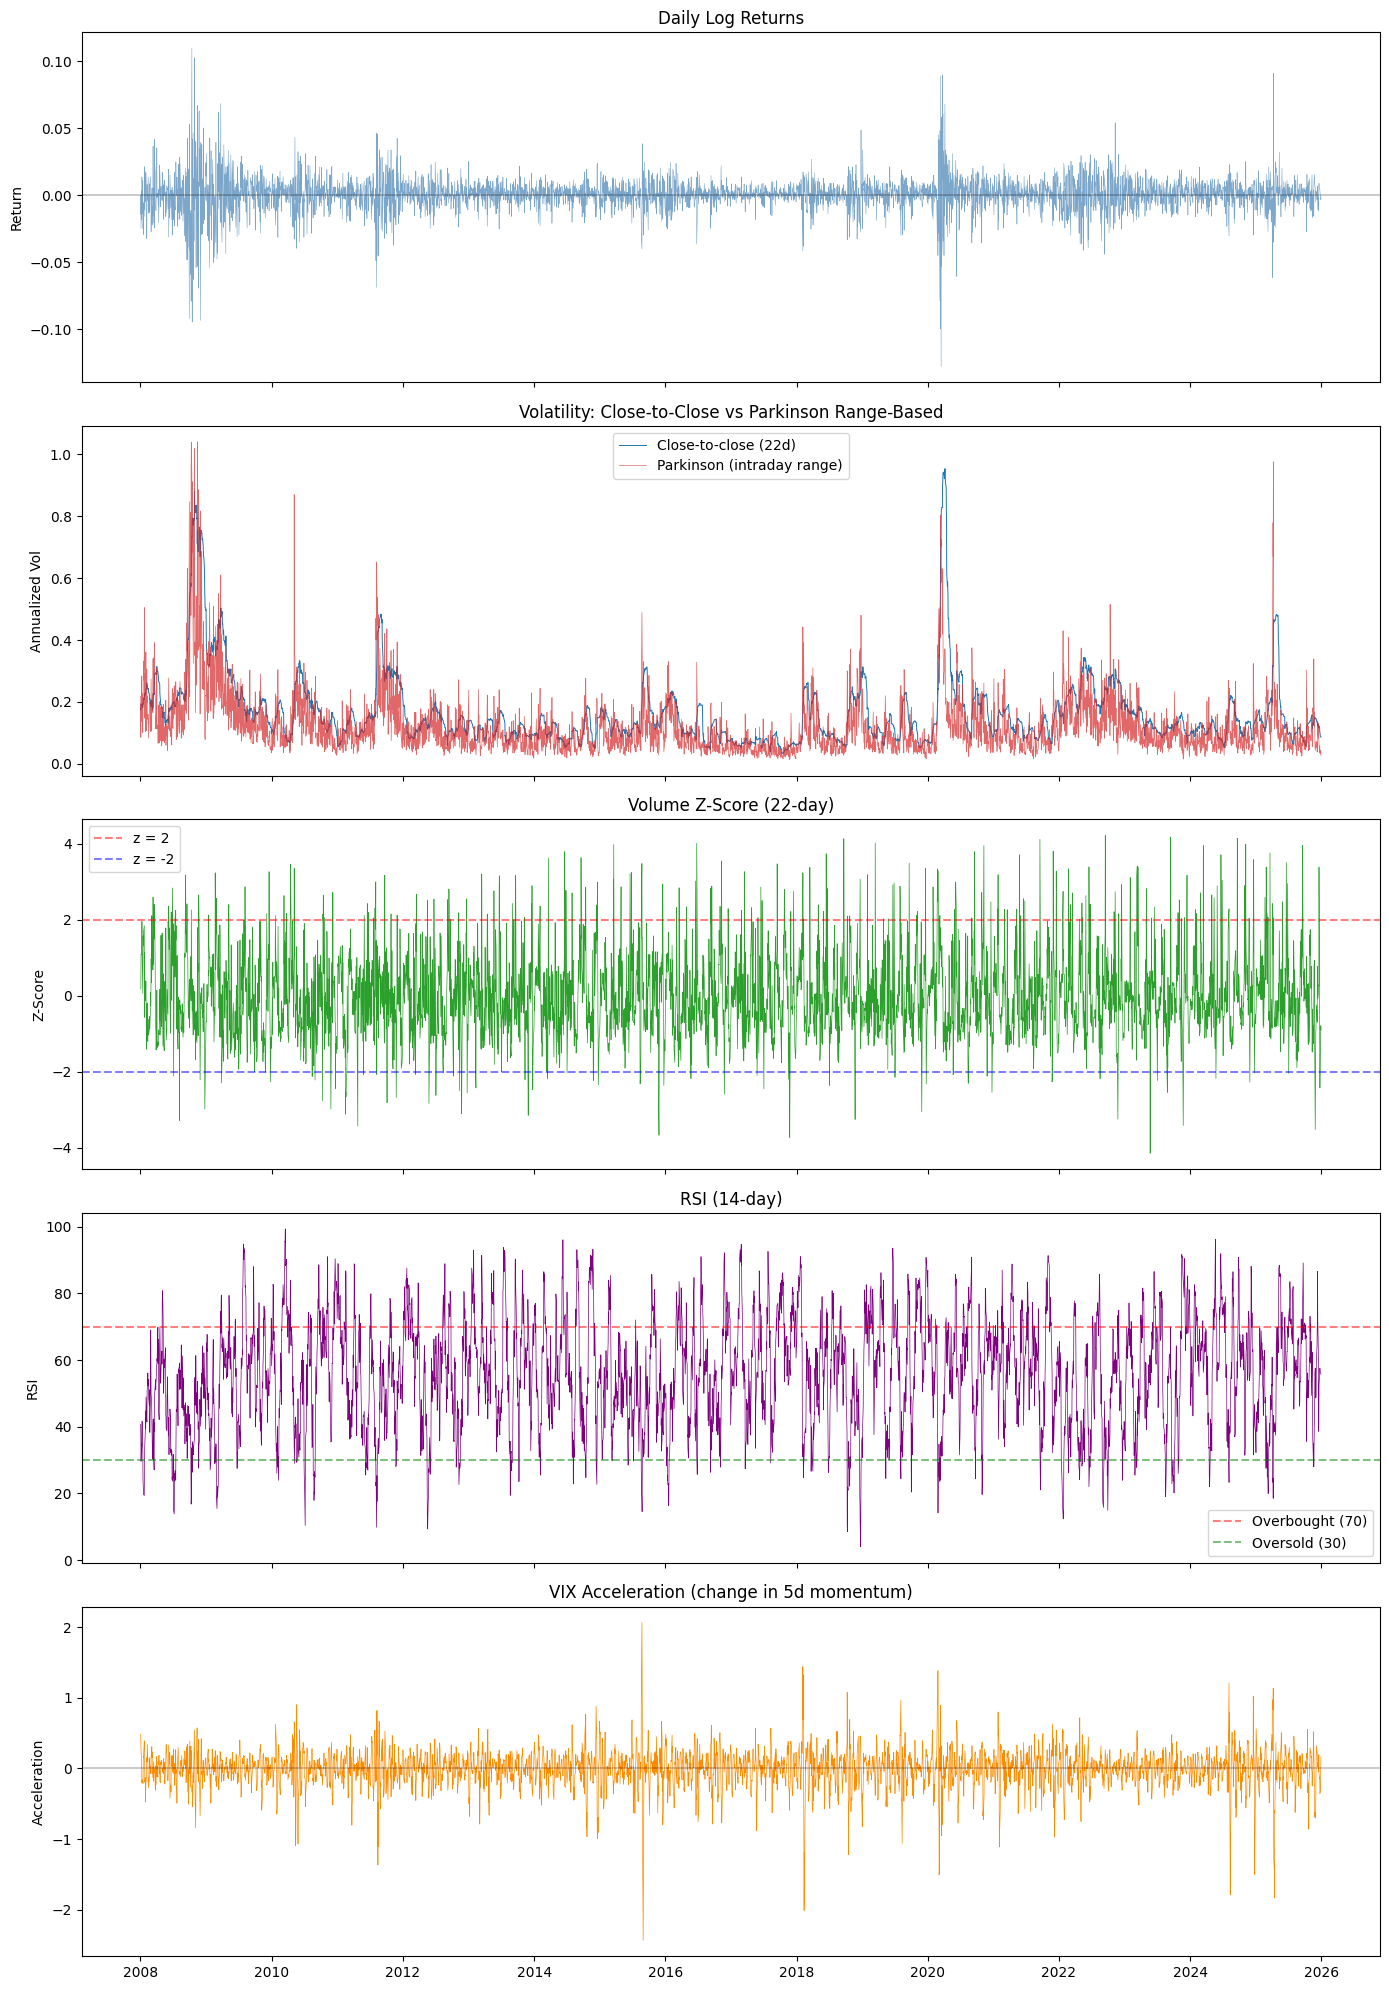

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)

# 1. Returns
ax = axes[0]
ax.plot(combined.index, combined["log_return"], linewidth=0.4, color="steelblue", alpha=0.7)
ax.set_title("Daily Log Returns")
ax.set_ylabel("Return")
ax.axhline(0, color="black", linewidth=0.3)

# 2. Close-to-close vol vs Parkinson vol
ax = axes[1]
ax.plot(combined.index, combined["vol_22d"], linewidth=0.7, label="Close-to-close (22d)", color="tab:blue")
ax.plot(combined.index, combined["parkinson_vol"], linewidth=0.5, label="Parkinson (intraday range)", color="tab:red", alpha=0.7)
ax.set_title("Volatility: Close-to-Close vs Parkinson Range-Based")
ax.set_ylabel("Annualized Vol")
ax.legend()

# 3. Volume z-score
ax = axes[2]
ax.plot(combined.index, combined["volume_zscore"], linewidth=0.5, color="tab:green")
ax.axhline(2, color="red", linestyle="--", alpha=0.5, label="z = 2")
ax.axhline(-2, color="blue", linestyle="--", alpha=0.5, label="z = -2")
ax.set_title("Volume Z-Score (22-day)")
ax.set_ylabel("Z-Score")
ax.legend()

# 4. RSI
ax = axes[3]
ax.plot(combined.index, combined["rsi_14"], linewidth=0.5, color="purple")
ax.axhline(70, color="red", linestyle="--", alpha=0.5, label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", alpha=0.5, label="Oversold (30)")
ax.set_title("RSI (14-day)")
ax.set_ylabel("RSI")
ax.legend()

# 5. VIX acceleration
ax = axes[4]
if "vix_acceleration" in combined.columns:
    ax.plot(combined.index, combined["vix_acceleration"], linewidth=0.5, color="darkorange")
    ax.axhline(0, color="black", linewidth=0.3)
    ax.set_title("VIX Acceleration (change in 5d momentum)")
    ax.set_ylabel("Acceleration")

plt.tight_layout()
plt.show()


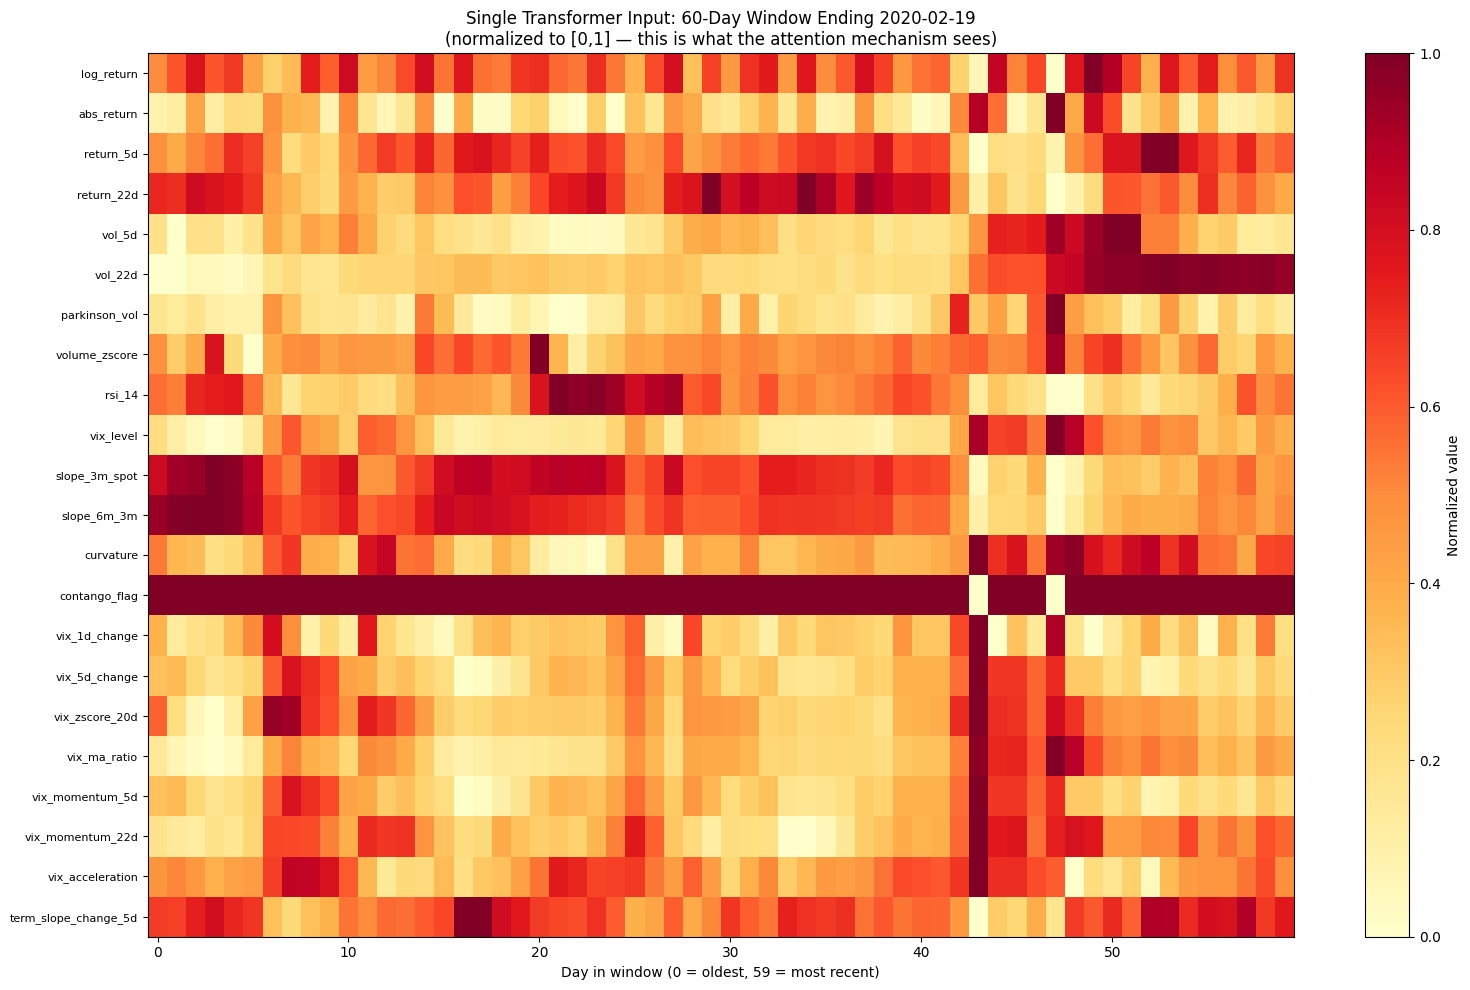

Window: 2019-11-21 to 2020-02-19
Shape: (60, 22)  (60 tokens x 22 features per token)

What happened next: COVID crash began Feb 20, 2020.
Can you see the signals building in the last few days of the window?


In [ ]:
# Visualize what a single Transformer input looks like:
# a 60-day window where each row is a day (token) and each column is a feature.
# This is exactly what the attention mechanism sees.

# Pick a window ending right before COVID crash (Feb 2020)
target_date = "2020-02-19"
closest_idx = combined.index.get_indexer([pd.Timestamp(target_date)], method="nearest")[0]
window_start = closest_idx - WINDOW + 1
window_end = closest_idx + 1

if window_start >= 0:
    window = combined.iloc[window_start:window_end].copy()

    # Normalize each feature to [0, 1] for visualization
    window_norm = (window - window.min()) / (window.max() - window.min() + 1e-10)

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(window_norm.T, aspect="auto", cmap="YlOrRd", interpolation="nearest")

    ax.set_yticks(range(len(window_norm.columns)))
    ax.set_yticklabels(window_norm.columns, fontsize=8)
    ax.set_xlabel("Day in window (0 = oldest, 59 = most recent)")
    ax.set_title(f"Single Transformer Input: 60-Day Window Ending {window.index[-1].date()}\n"
                 f"(normalized to [0,1] — this is what the attention mechanism sees)")
    plt.colorbar(im, label="Normalized value")
    plt.tight_layout()
    plt.show()

    print(f"Window: {window.index[0].date()} to {window.index[-1].date()}")
    print(f"Shape: {window.shape}  (60 tokens x {window.shape[1]} features per token)")
    print(f"\nWhat happened next: COVID crash began Feb 20, 2020.")
    print(f"Can you see the signals building in the last few days of the window?")
else:
    print("Not enough data for this window — try a later date.")


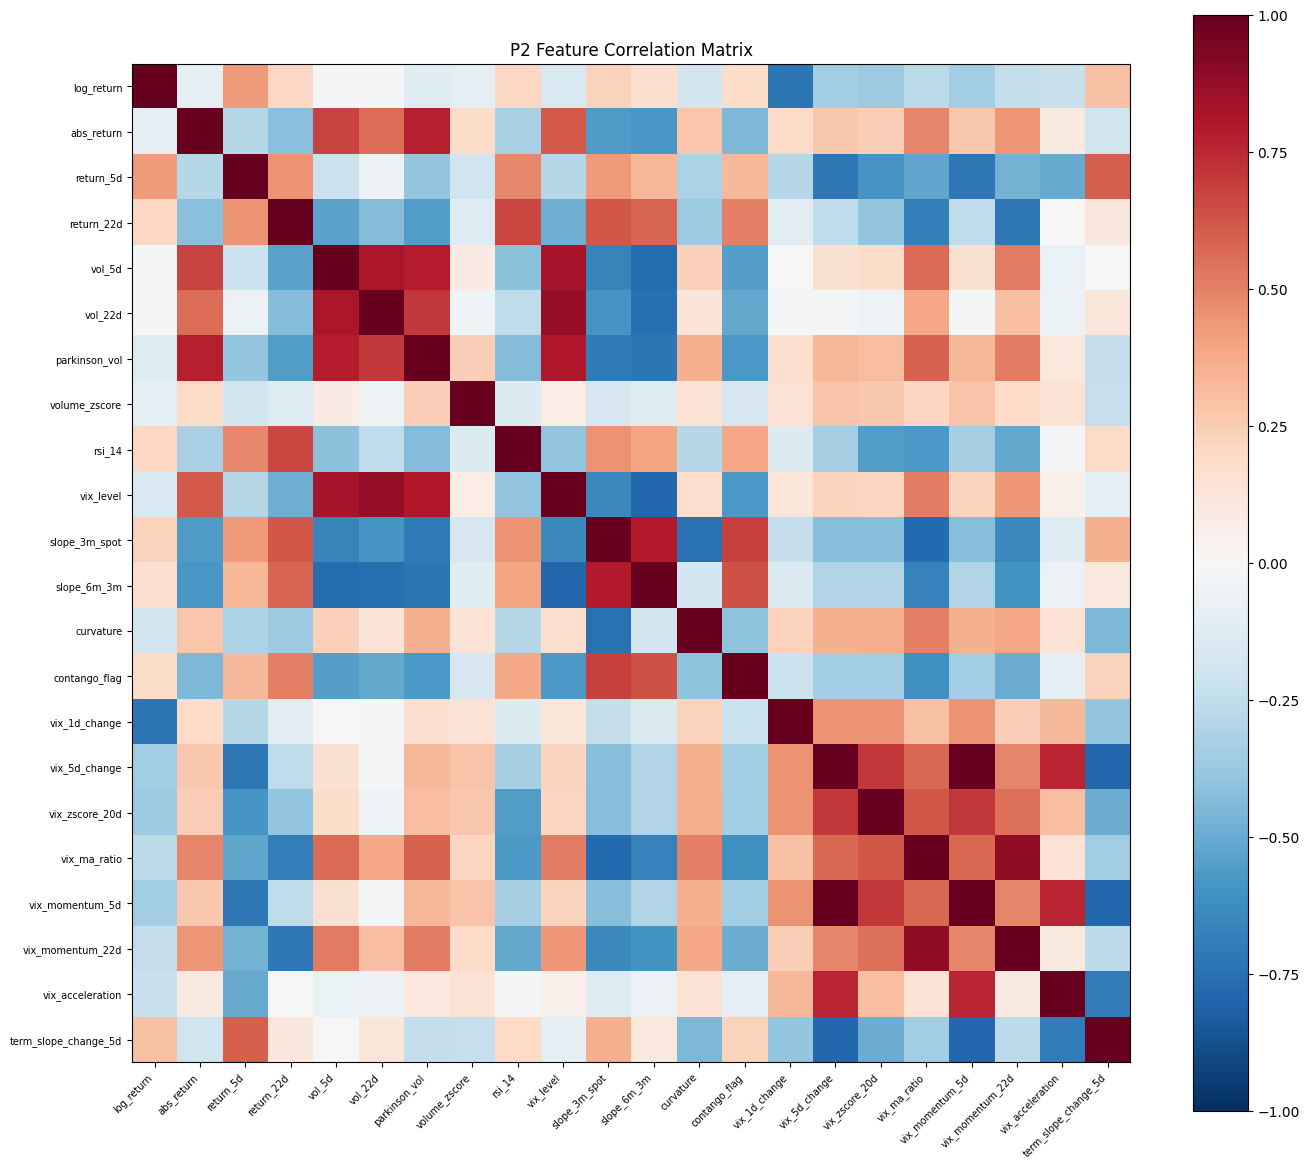


Highly correlated pairs (|r| > 0.9):
  vix_5d_change <-> vix_momentum_5d: 1.000


In [ ]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = combined.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
plt.colorbar(im)
ax.set_title("P2 Feature Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nHighly correlated pairs (|r| > 0.9):")
found = False
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.9:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")
            found = True
if not found:
    print("  None — good feature diversity.")
